 -*- coding: utf-8 -*-  <br>
 MBA Data Science e Analytics USP/ESALQ <br>
 Código para o desenvolvimento do TCC - Parte 02 <br>
 Autor: Ronaldo do Couto Silva Filho


 ### 4. Aplicação de Técnicas de Machine Learning
 Aplicar técnicas de Machine Learning para Analisar dados e fazer previsões,
 validações e testes serão realizados na sequencia sem a devida separação em
 tópicos

In [ ]:
import os
import random
from time import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

from utils import formatar_grafico_mbausp, read_parquet_with_source

In [ ]:
# Definir a seed para reprodutibilidade
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

initializer = tf.keras.initializers.GlorotUniform(seed=seed)

tf.config.experimental.enable_op_determinism()

In [ ]:
# Carga e Pré-Processamento dos Dados

# Nesse momento carrega-se a base de dados a ser analisada

# # 30 min
# df = read_parquet_with_source("../databases_parquet/sol_30min")
# df = read_parquet_with_source("../databases_parquet/eth_30min")

# # 1 hora
# df = read_parquet_with_source("../databases_parquet/sol_1hr")
# df = read_parquet_with_source("../databases_parquet/eth_1hr")

# # 1 dia
df = read_parquet_with_source("../databases_parquet/sol_1dia")
# df = read_parquet_with_source("../databases_parquet/eth_1dia")

In [ ]:
# Segregar o dataset em dados de treino, validação e teste

# Para um DataFrame que se chama "df" e contém as colunas:
# timestamp, close, volume, number_of_trades, return_pct, SMA_10, EMA_10, RSI
features = ['return_pct', 'SMA_10', 'EMA_10', 'RSI']  # Variáveis preditoras
target = ['close']  # Variável a ser prevista

def segrega_data_set_val(df, target='close', features=features,
                         prop_treino=0.6, prop_val=0.2): 
    # Proporções
    train_size = int(len(df) * prop_treino)
    val_size = int(len(df) * prop_val)
    
    # Divisão em treino e teste
    train = df[:train_size]
    val = df[train_size:train_size+val_size]
    test_data = df[train_size+val_size:]

    # Verificando as divisões
    print(
    f'Tamanho treino: {len(train)}, validação: {len(val)}, teste: {len(test_data)}'
    )

    X_train, y_train = train[features], train[target]
    X_val, y_val = val[features], val[target]
    X_test, y_test = test_data[features], test_data[target]

    return X_train, y_train, X_val, y_val, X_test, y_test, test_data

X_train, y_train, X_val, y_val, X_test, y_test, test_data = segrega_data_set_val(df)

Tamanho treino: 944, validação: 314, teste: 316


In [ ]:
# Aplicar a normalização dos dados de treino do modelo

def normaliza_dados_val(
        X_train = X_train, X_val = X_val, X_test = X_test,
        y_train = y_train, y_val = y_val, y_test = y_test):

    # Normalizar cada parte SEPARADAMENTE para evitar data leakage
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    # Ajustar o fit e transformar: Compute the mean and std, then transform it.
    X_train_scaled = scaler_X.fit_transform(X_train)
    y_train_scaled = scaler_y.fit_transform(y_train.to_frame())

    # Transforma/Padroniza os dados com base na média e no std calculados
    X_val_scaled = scaler_X.transform(X_val)
    X_test_scaled = scaler_X.transform(X_test)

    y_val_scaled = scaler_y.transform(y_val.to_frame())
    y_test_scaled = scaler_y.transform(y_test.to_frame())


    return (X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, 
            y_val_scaled, y_test_scaled, scaler_X, scaler_y)

(X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, y_val_scaled, 
        y_test_scaled, scaler_X, scaler_y) = normaliza_dados_val()

In [ ]:
# Aplicar o Algoritmoo Naive
results = {}

def modela_Naive(df, test=test_data, target=target):
    # Tempo inicial
    start_time = time()

    # Criando a coluna de valores previstos
    test['predicted_naive']=test[target][0]

    # Copiando o primeiro valor real do conjunto de teste para valores previstos
    test['predicted_naive'][0]=test[target][0]

    # Calcular o erro (exemplo: MAE)
    mae = mean_absolute_error(test[target].iloc[1:], 
                              test['predicted_naive'].iloc[1:])

    mse = mean_squared_error(test[target].iloc[1:], 
                                            test['predicted_naive'].iloc[1:])

    rmse = np.sqrt(mse)

    # Calculo de Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    metricas_benchmark = [mae, mse, rmse, 'NA', execution_time]

    # Nome dinâmico da variável, ex: "sol_1dia_Naive"
    var_name = f"{df.attrs['source']}_Naive"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = metricas_benchmark

    print(f'MAE_test do Benchmark: {mae: .2f}')
    print(f'MSE_test do Benchmark: {mse: .2f}')
    print(f'RMSE_test do Benchmark: {rmse: .2f}')
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    return metricas_benchmark

metricas_benchmark = modela_Naive(df,target='close')

MAE_test do Benchmark:  60.79
MSE_test do Benchmark:  4794.55
RMSE_test do Benchmark:  69.24
O tempo que o modelo levou para treinar foi de: 0.0030083656311035156


<ipython-input-6-3f1c19efb2d5>:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive']=test[target][0]
<ipython-input-6-3f1c19efb2d5>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['predicted_naive']=test[target][0]
<ipython-input-6-3f1c19efb2d5>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive'][0]=test[target][0]
<ipython-input

In [ ]:
# Criação de Janelas Deslizantes

# Os Algoritmos de redes neurais em especial de séries temporais permitem que o 
# modelo capture dependências temporais e padrões em diferentes intervalos de 
# tempo.

def create_sequences(X_data, y_data, time_steps=10):
    """ Função desenvolvida para a criação de janelas deslizantes para 
    séries temporais. 
    A função recebe valores X e Y, e por default utiliza um time_step = 10"""
    X_seq, y_seq = [], []
    for i in range(len(X_data) - time_steps):
        X_seq.append(X_data[i:i + time_steps])  # 10 passos de entrada
        y_seq.append(y_data[i + time_steps])  # Próximo valor de "close"

    return np.array(X_seq), np.array(y_seq)

# Definir o tamanho da janela deslizante
time_steps = 10

# Criar janelas para treino, validação e teste
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

# Ajustar o formato para redes neurais 
X_train_seq = X_train_seq.reshape(
    X_train_seq.shape[0], X_train_seq.shape[1], X_train_seq.shape[2])

X_val_seq = X_val_seq.reshape(
    X_val_seq.shape[0], X_val_seq.shape[1], X_val_seq.shape[2])

X_test_seq = X_test_seq.reshape(
    X_test_seq.shape[0], X_test_seq.shape[1], X_test_seq.shape[2])

In [ ]:
# Criar Modelos: LSTM

def model_lstm_function(
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq, 
        activation = 'relu'):
    
    start_time = time()

    # Criar Modelo
    model_lstm = Sequential([
        LSTM(units=100, activation=activation, return_sequences=True, 
             input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        LSTM(units=100, activation=activation, return_sequences=False),
        Dense(1)
    ])

    # Compilar
    learning_rate = 0.0001
    optimizer = Adam(learning_rate=learning_rate)
    model_lstm.compile(optimizer=optimizer, loss='mean_squared_error')

    # Via de regra Keras/TensorFlow trabalha melhor em float32 assim:
    X_train_seq = X_train_seq.astype("float32")
    y_train_seq = y_train_seq.astype("float32")
    X_val_seq   = X_val_seq.astype("float32")
    y_val_seq   = y_val_seq.astype("float32")

    # Configura Callbacks
    # EarlyStopping
    early_stop = EarlyStopping(
        monitor='val_loss',   # monitora a perda de validação
        patience=5,           # espera 5 épocas sem melhoria
        verbose=1,            # imprime mensagem quando parar
        min_delta = 1e-4,     # melhoria significativa é na quarta decimal
        restore_best_weights=True  # restaura os pesos da melhor época
    )

    # Treinar
    history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq, 
    epochs=50, batch_size=32, 
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop],
    verbose=1)

    end_time = time()
    execution_time = end_time - start_time
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    return execution_time, model_lstm

In [ ]:
# Criar Modelos: GRU

def model_gru_function(
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq, 
        activation = 'relu'):
    
    start_time = time()

    # Criar Modelo
    model_gru = Sequential([
        GRU(units=100, activation=activation, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),#testado com tanh
        GRU(units=100, activation=activation, return_sequences=False),
        Dense(1)
    ])

    # Compilar
    learning_rate = 0.0001
    optimizer = Adam(learning_rate=learning_rate)
    model_gru.compile(optimizer=optimizer, loss='mean_squared_error')

    # Via de regra Keras/TensorFlow trabalha melhor em float32 assim:
    X_train_seq = X_train_seq.astype("float32")
    y_train_seq = y_train_seq.astype("float32")
    X_val_seq   = X_val_seq.astype("float32")
    y_val_seq   = y_val_seq.astype("float32")

    # Configura Callbacks
        # EarlyStopping
    early_stop = EarlyStopping(
        monitor='val_loss',   # monitora a perda de validação
        patience=5,           # espera 5 épocas sem melhoria
        verbose=1,            # imprime mensagem quando parar
        min_delta = 1e-4,     # melhoria significativa é na quarta decimal
        restore_best_weights=True  # restaura os pesos da melhor época
    )

    history_gru = model_gru.fit(
    X_train_seq, y_train_seq, 
    epochs=50, batch_size=32, 
    validation_data=(X_val_seq, y_val_seq), 
    callbacks=[early_stop],
    verbose=1)

    # Devido a constantes erros no Treino da Rede GRU, não foi aplicada o EarlyStop

    end_time = time()
    execution_time = end_time - start_time
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    return execution_time, model_gru

In [ ]:
# Chamada da função LSTM
time_lstm, model_lstm= model_lstm_function(
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq)

Epoch 1/50


c:\Users\rofil\Documents\MBA-USP_ESALQ\TCC\01_Meu_Projeto\00_Codigo\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.9611 - val_loss: 0.2272
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7634 - val_loss: 0.1351
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4983 - val_loss: 0.0464
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1577 - val_loss: 0.0112
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0542 - val_loss: 0.0088
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0424 - val_loss: 0.0069
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0367 - val_loss: 0.0061
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0323 - val_loss: 0.0055
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0290 - val_loss: 0.0051
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0264 - val_loss: 0.0047
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0242 - val_loss: 0.0045
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0224 - val_loss: 0.00

In [ ]:
# Chamada da função GRU
time_gru, model_gru= model_gru_function(
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.8353 - val_loss: 0.2320
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5442 - val_loss: 0.1345
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2734 - val_loss: 0.0496
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839 - val_loss: 0.0155
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0404 - val_loss: 0.0107
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0284 - val_loss: 0.0072
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0211 - val_loss: 0.0052
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0167 - val_loss: 0.0042
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0139 - val_loss: 0.0036
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0120 - val_loss: 0.0033
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0106 - val_loss: 0.0030
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0096 - val_l

In [ ]:
# Fazer Previsões

# Previsão com LSTM

# # Conjunto de Validação

y_val_pred_lstm = model_lstm.predict(X_val_seq)

rmse_lstm_val = np.sqrt(mean_squared_error(y_val_seq, y_val_pred_lstm))
print("LSTM RMSE Validação:", rmse_lstm_val)

# # Conjunto de Teste

y_pred_lstm = model_lstm.predict(X_test_seq)

mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
mse_lstm = mean_squared_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
mase_lstm = mae_lstm/metricas_benchmark[1]

# # Nome dinâmico da variável, ex: "sol_1dia_LSTM"
var_name = f"{df.attrs['source']}_LSTM"

results[var_name] = [mae_lstm, mse_lstm, rmse_lstm, mase_lstm, time_lstm]

print_metricas_lstm = [
    f"LSTM MAE Teste: {mae_lstm}",
    f"LSTM MSE Teste: {mse_lstm}",
    f"LSTM RMSE Teste: {rmse_lstm}",
    f"LSTM MASE Teste: {mase_lstm}"]

print("\n".join(print_metricas_lstm))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
LSTM RMSE Validação: 0.049957850275621364
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
LSTM MAE Teste: 0.13685585010383472
LSTM MSE Teste: 0.027343873983095825
LSTM RMSE Teste: 0.16535983183075575
LSTM MASE Teste: 2.8544065262213273e-05


In [ ]:
# Previsão com GRU

y_val_pred_gru = model_gru.predict(X_val_seq)

rmse_gru_val = np.sqrt(mean_squared_error(y_val_seq, y_val_pred_gru))
print("GRU RMSE Validação:", rmse_gru_val)

# # Conjunto de Teste

y_pred_gru = model_gru.predict(X_test_seq)

mae_gru = mean_absolute_error(y_test_seq, y_pred_gru)
mse_gru = mean_squared_error(y_test_seq, y_pred_gru)
rmse_gru = np.sqrt(mse_gru)
mase_gru = mae_gru/metricas_benchmark[1]

# # Nome dinâmico da variável, ex: "sol_1dia_GRU"
var_name = f"{df.attrs['source']}_GRU"

results[var_name] = [mae_gru, mse_gru, rmse_gru, mase_gru, time_gru]

print_metricas_gru = [
    f"GRU MAE Teste: {mae_gru}",
    f"GRU MSE Teste: {mse_gru}",
    f"GRU RMSE Teste: {rmse_gru}",
    f"GRU MASE Teste: {mase_gru}"]

print("\n".join(print_metricas_gru))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
GRU RMSE Validação: 0.0471479091070747
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
GRU MAE Teste: 0.08826132577192007
GRU MSE Teste: 0.012696812426770027
GRU RMSE Teste: 0.11268013323904985
GRU MASE Teste: 1.8408690903981755e-05


In [ ]:
# Desnormalizar os Resultados

def inverse_transform_y(scaler, data):
    """Desfaz normalização de y (1D)."""
    return scaler.inverse_transform(data.reshape(-1, 1)).ravel()

y_pred_lstm = inverse_transform_y(scaler_y, y_pred_lstm)
y_pred_gru = inverse_transform_y(scaler_y, y_pred_gru)
y_test_real = inverse_transform_y(scaler_y, y_test_scaled)

Gráfico salvo como: ../graficos\sol_1dia_LSTM_forecast.jpg


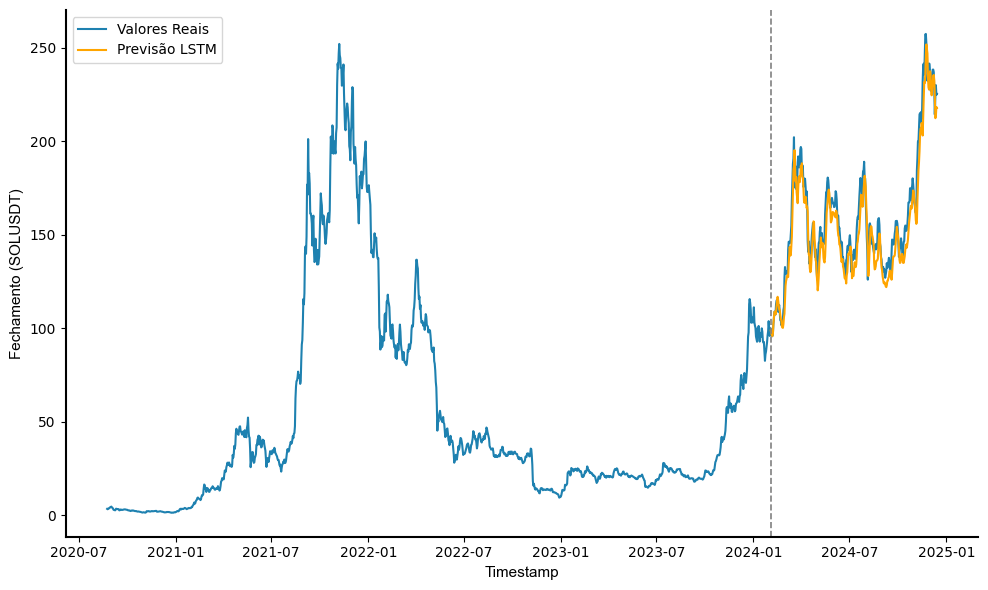

Gráfico salvo como: ../graficos\sol_1dia_GRU_forecast.jpg


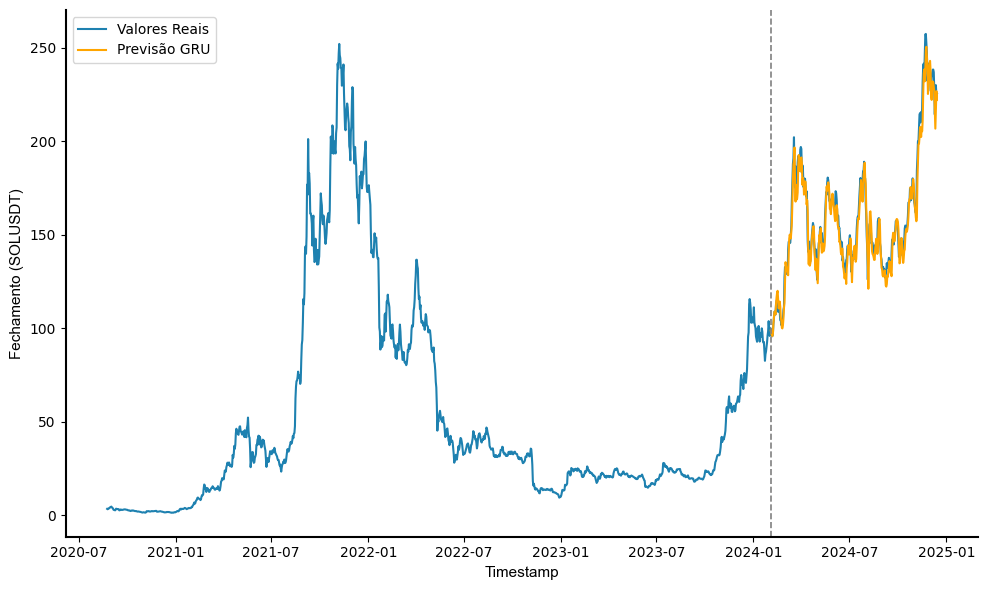

In [ ]:
# Visualizar Resultados

# Ao utilizar janelas deslizantes diminuimos a quantidade de valores previstos
# contornamos isso, adicionando a mesma quantidade de valores de y_test que o 
# número de janelas deslizantes

# Converter para Series ajustando o índice
y_pred_lstm_s = pd.Series(y_pred_lstm, index=y_test[time_steps:].index)
y_pred_gru_s = pd.Series(y_pred_gru, index=y_test[time_steps:].index)

# 1. Vizualizar resultados de LSTM

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_val, y_test])
y_pred = pd.concat([y_test[:time_steps], y_pred_lstm_s])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão LSTM": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_LSTM_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    legenda = True,
    vertical = True
)

# 2. Vizualizar resultados de GRU
# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_val, y_test])
y_pred = pd.concat([y_test[:time_steps], y_pred_gru_s])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão GRU": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_GRU_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    legenda = True,
    vertical = True
)

In [ ]:
os.makedirs("../Resultados_LSTM_GRU", exist_ok=True)
caminho_results = os.path.join("../Resultados_LSTM_GRU", f"LSTM_GRU-{df.attrs['source']}.csv")

arquivo = pd.DataFrame(results)
arquivo.to_csv(caminho_results, index = False)